# INSURANCE CLAIMS FRAUD DETECTION — End-to-End Machine Learning Pipeline

This notebook covers:
- **Epic 2**: Data Collection & Preparation
- **Epic 3**: Exploratory Data Analysis (Descriptive + Visual)
- **Epic 4**: Model Building (Logistic Regression, Decision Tree, Random Forest, XGBoost)
- **Epic 5**: Performance Testing & Hyperparameter Tuning
- **Epic 6**: Web Framework Integration

In [427]:
import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

%matplotlib inline

## EPIC 2 — DATA COLLECTION & PREPARATION

  EPIC 2: DATA COLLECTION & PREPARATION

✅ Dataset loaded via read_csv(): 1000 rows × 40 columns

Visualizing requested boxplots for policy_number and months_as_customer...


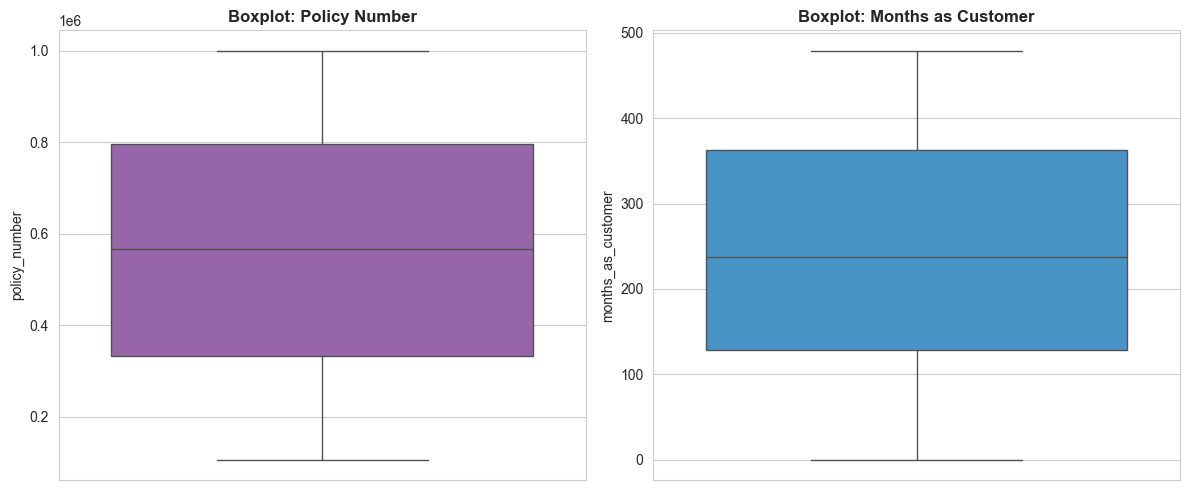

Dropped columns: ['_c39', 'policy_number', 'policy_bind_date', 'incident_date', 'incident_location', 'insured_zip', 'incident_city', 'auto_model', 'age', 'injury_claim', 'property_claim', 'vehicle_claim']
Remaining: 28 columns



In [428]:
print("=" * 70)
print("  EPIC 2: DATA COLLECTION & PREPARATION")
print("=" * 70)

# Load dataset
df = pd.read_csv("insurance_fraud_dataset.csv")
print(f"\n✅ Dataset loaded via read_csv(): {df.shape[0]} rows × {df.shape[1]} columns\n")

# --- 2.0 Visualizing Raw Features ---
print("Visualizing requested boxplots for policy_number and months_as_customer...")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if "policy_number" in df.columns:
    sns.boxplot(y=df["policy_number"], ax=axes[0], color="#9b59b6")
    axes[0].set_title("Boxplot: Policy Number", fontweight="bold")

if "months_as_customer" in df.columns:
    sns.boxplot(y=df["months_as_customer"], ax=axes[1], color="#3498db")
    axes[1].set_title("Boxplot: Months as Customer", fontweight="bold")

plt.tight_layout()
plt.show()

# --- 2.1 Drop irrelevant and highly correlated columns ---
drop_cols = ["_c39", "policy_number", "policy_bind_date", "incident_date",
             "incident_location", "insured_zip", "incident_city", "auto_model"]

# Highly correlated features identified during multivariate analysis:
# - age: highly correlated with months_as_customer (0.92)
# - injury_claim, property_claim, vehicle_claim: highly correlated with total_claim_amount
corr_drop_cols = ["age", "injury_claim", "property_claim", "vehicle_claim"]
final_drop = drop_cols + corr_drop_cols

df.drop(columns=[c for c in final_drop if c in df.columns], inplace=True)
print(f"Dropped columns: {final_drop}")
print(f"Remaining: {df.shape[1]} columns\n")

# --- 2.2 Encoding target ---
if "fraud_reported" in df.columns and df["fraud_reported"].dtype == "object":
    df["fraud_reported"] = df["fraud_reported"].map({"Y": 1, "N": 0})

### Missing Values

For checking the null values, **df.isna().any()** function is used. To sum those null values we use **.sum()** function. From the below image we found that there are no null values present in our dataset. So we can skip handling the missing values step.

In [429]:
# Checking for null values
print("Checking for null values using isna().any():")
print(df.isna().any())

print("\nSumming null values using isna().sum():")
print(df.isna().sum())

Checking for null values using isna().any():
months_as_customer             False
policy_state                   False
policy_csl                     False
policy_deductable              False
policy_annual_premium          False
umbrella_limit                 False
insured_sex                    False
insured_education_level        False
insured_occupation             False
insured_hobbies                False
insured_relationship           False
capital-gains                  False
capital-loss                   False
incident_type                  False
collision_type                 False
incident_severity              False
authorities_contacted           True
incident_state                 False
incident_hour_of_the_day       False
number_of_vehicles_involved    False
property_damage                False
bodily_injuries                False
witnesses                      False
police_report_available        False
total_claim_amount             False
auto_make                     

### Encoding the Categorical Features

The categorical Features are can’t be passed directly to the Machine Learning Model. So we convert them into Numerical data based on their order. This Technique is called Encoding.

• Here we are importing **Label Encoder** from the Sklearn Library.

• Here we are applying **fit_transform** to transform the categorical features to numerical features.

In [430]:
label_encoders = {}
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print(f"Encoded {len(cat_cols)} categorical columns.")

Encoded 15 categorical columns.


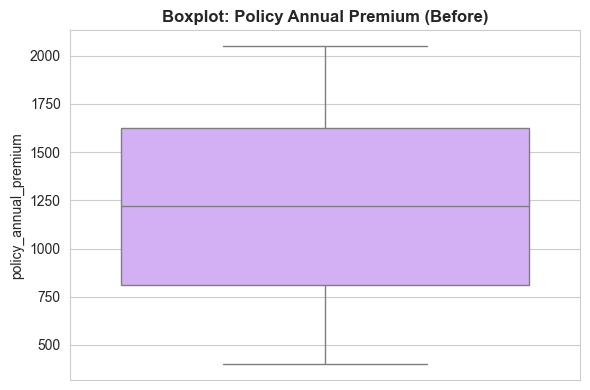

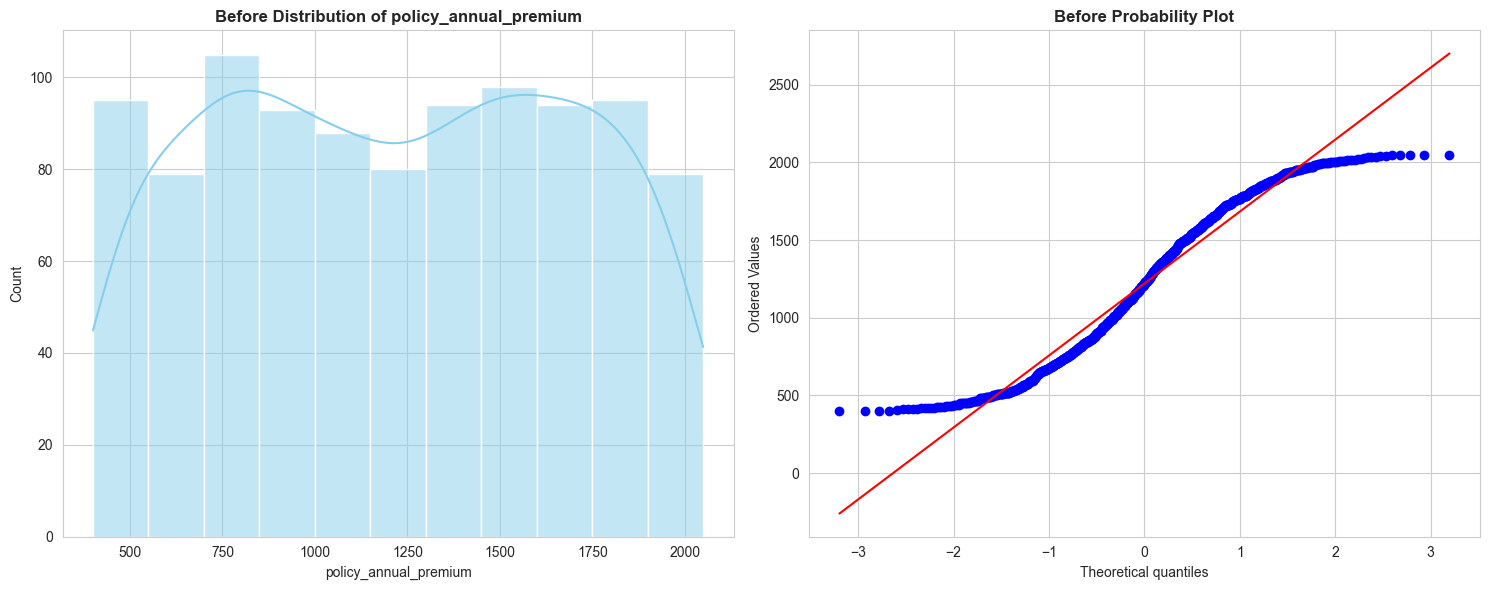


✅ Log transformation applied to policy_annual_premium & months_as_customer


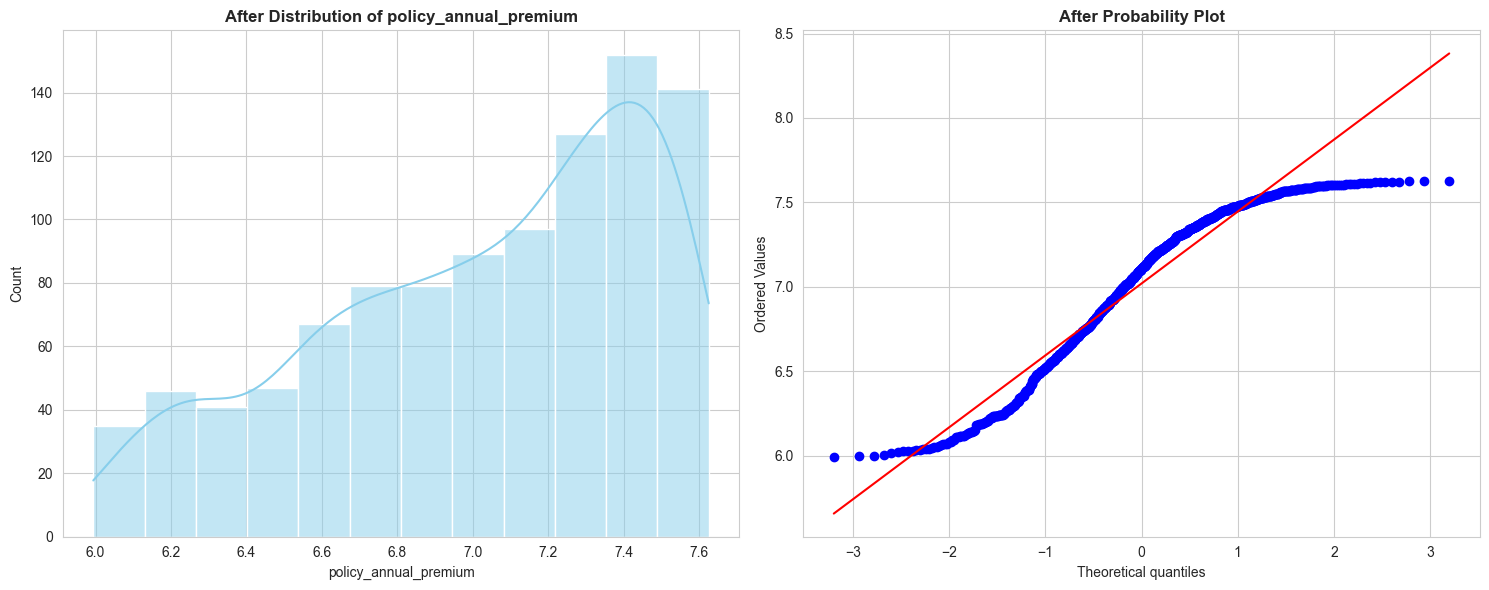

In [431]:
# --- 2.4 Handling Outliers ---
def plot_distribution_prob(df, feature, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.histplot(df[feature], kde=True, ax=axes[0], color="skyblue")
    axes[0].set_title(f"{title_prefix} Distribution of {feature}", fontweight="bold")
    stats.probplot(df[feature], dist="norm", plot=axes[1])
    axes[1].set_title(f"{title_prefix} Probability Plot", fontweight="bold")
    plt.tight_layout()
    plt.show()

# Visualize before
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(y=df["policy_annual_premium"], ax=ax, color="#D4A5FF")
ax.set_title("Boxplot: Policy Annual Premium (Before)", fontweight="bold")
plt.tight_layout()
plt.show()

plot_distribution_prob(df, "policy_annual_premium", "Before")

# Apply Log Transformation
df["policy_annual_premium"] = np.log1p(df["policy_annual_premium"])
df["months_as_customer"]    = np.log1p(df["months_as_customer"])
print("\n✅ Log transformation applied to policy_annual_premium & months_as_customer")

# Visualize after
plot_distribution_prob(df, "policy_annual_premium", "After")

## EPIC 3 — EXPLORATORY DATA ANALYSIS

In [432]:
# --- 3.1 Descriptive Statistics ---
print(df.describe().round(2).to_string())
print(f"\nTarget distribution:\n{df['fraud_reported'].value_counts().to_string()}")

       months_as_customer  policy_state  policy_csl  policy_deductable  policy_annual_premium  umbrella_limit  insured_sex  insured_education_level  insured_occupation  insured_hobbies  insured_relationship  capital-gains  capital-loss  incident_type  collision_type  incident_severity  authorities_contacted  incident_state  incident_hour_of_the_day  number_of_vehicles_involved  property_damage  bodily_injuries  witnesses  police_report_available  total_claim_amount  auto_make  auto_year  fraud_reported
count             1000.00       1000.00     1000.00            1000.00                1000.00         1000.00       1000.0                  1000.00             1000.00          1000.00               1000.00        1000.00       1000.00        1000.00         1000.00            1000.00                1000.00         1000.00                   1000.00                      1000.00          1000.00          1000.00    1000.00                  1000.00             1000.00    1000.00    1000.00 

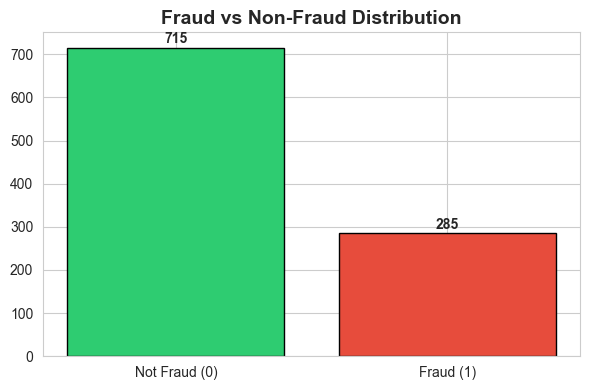

In [433]:
# Plot 1: Target distribution (Countplot)
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["fraud_reported"].value_counts()
bars = ax.bar(["Not Fraud (0)", "Fraud (1)"], counts.values,
              color=["#2ecc71", "#e74c3c"], edgecolor="black")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 10,
            str(int(b.get_height())), ha="center", fontweight="bold")
ax.set_title("Fraud vs Non-Fraud Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

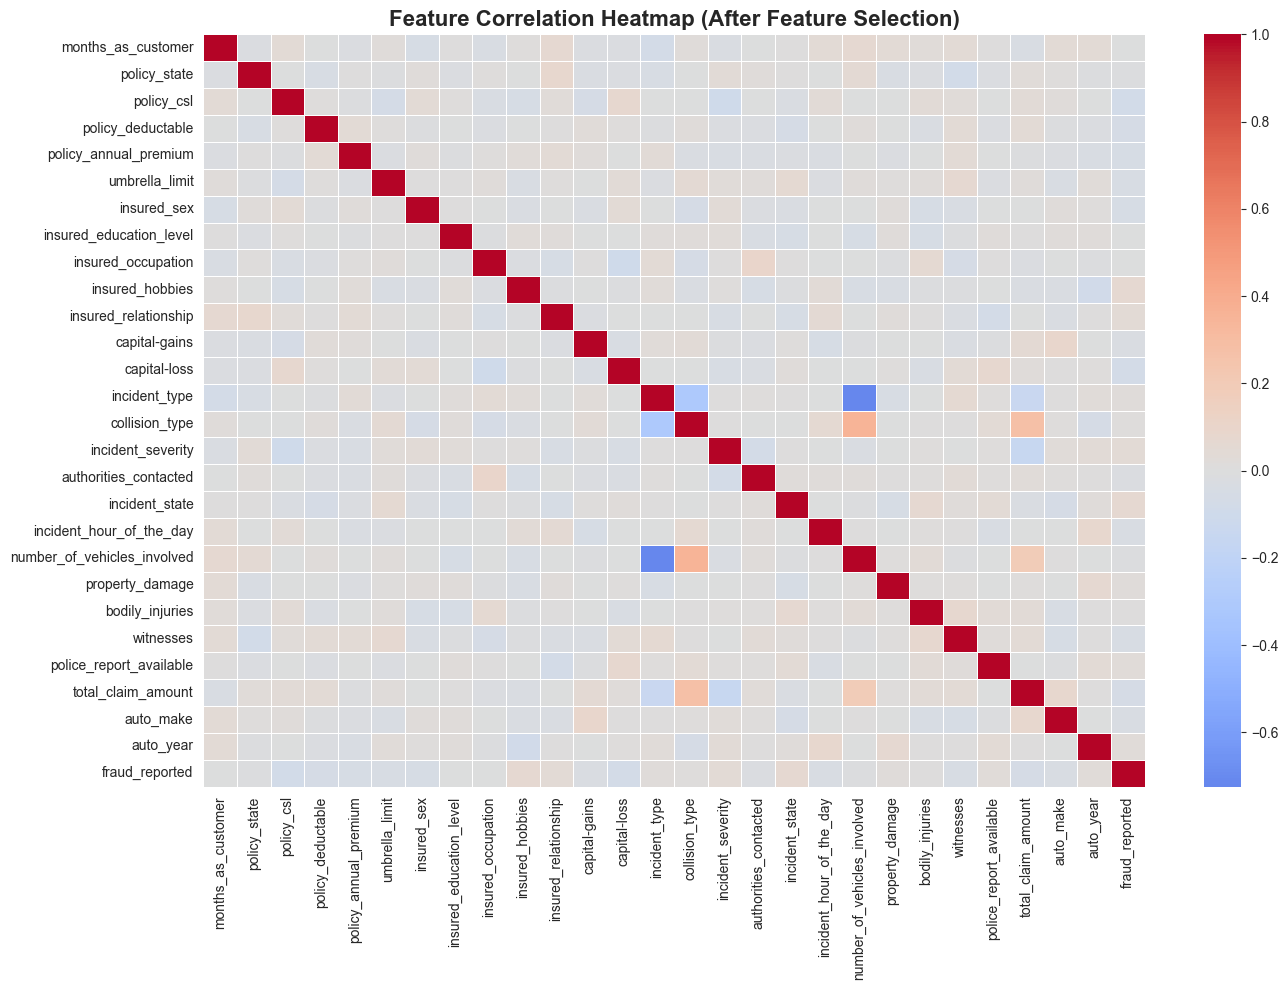

In [434]:
# Plot 2: Correlation heatmap (Multivariate Analysis)
fig, ax = plt.subplots(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm", center=0, 
            linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Heatmap (After Feature Selection)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

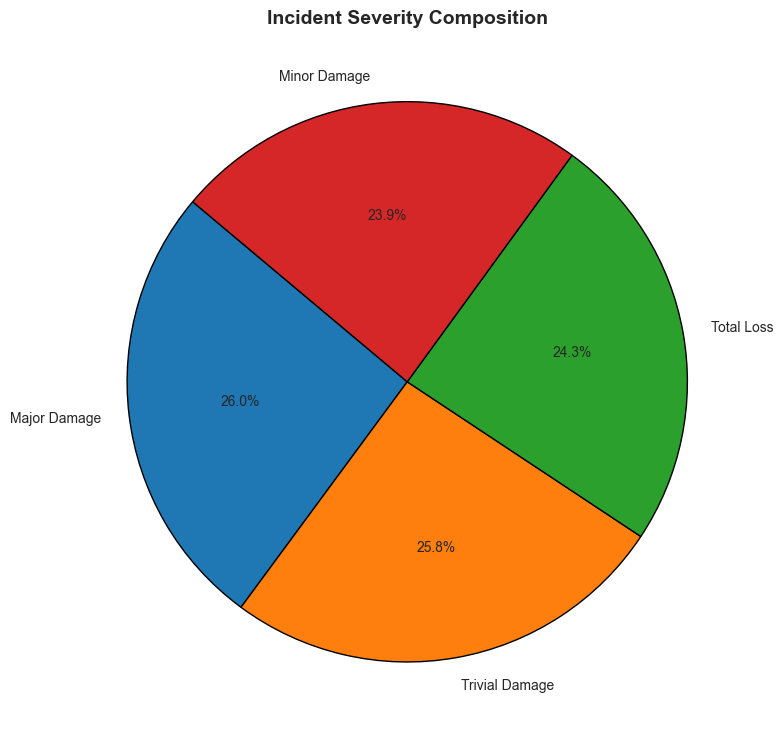

In [435]:
# Plot 8: Incident severity composition (Pie Chart)
if "incident_severity" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 8))
    counts = df["incident_severity"].value_counts()
    # Attempting to use inverse transform if encoder exists for better labels
    if "incident_severity" in label_encoders:
        labels = label_encoders["incident_severity"].inverse_transform(counts.index)
    else:
        labels = counts.index
    ax.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
    ax.set_title("Incident Severity Composition", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

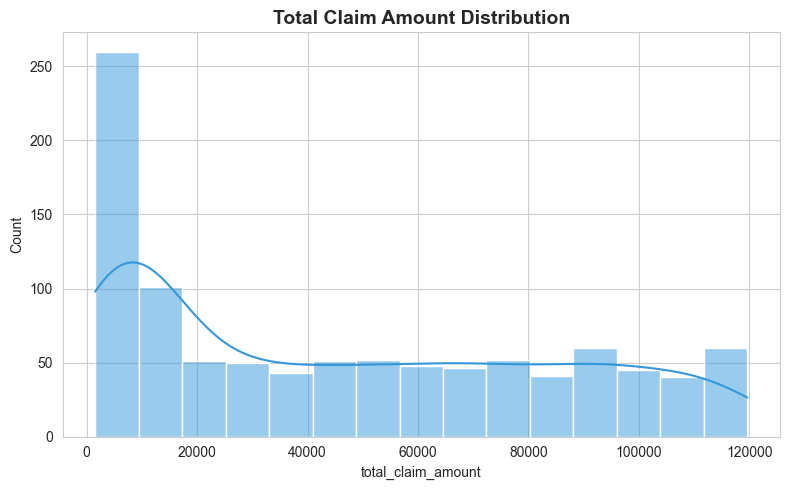

In [436]:
# Plot 9: Total Claim Amount Distribution (Histogram)
if "total_claim_amount" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(df["total_claim_amount"], kde=True, color="#3498db", ax=ax, bins=15)
    ax.set_title("Total Claim Amount Distribution", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## EPIC 4 — MODEL BUILDING

### Splitting data into train and test

Now let’s split the Dataset into train and test sets. First split the dataset into x and y and then split the data set Here x and y variables are created. On x variable, df is passed with dropping the target variable. And on y target variable is passed. For splitting training and testing data we are using **train_test_split()** function from sklearn. As parameters, we are passing x, y, test_size, random_state.

In [437]:
X = df.drop("fraud_reported", axis=1)
y = df["fraud_reported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Training set: 800 samples
Testing set:  200 samples


### Scaling

• Scaling is a technique used to transform the values of a dataset to a similar scale to improve the performance of machine learning algorithms. Scaling is important because many machine learning algorithms are sensitive to the scale of the input features.

• Here we are using **Standard Scaler**.

• This scales the data to have a mean of 0 and a standard deviation of 1. The formula is given by: **X_scaled = (X - X_mean) / X_std**

In [438]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("✅ Data scaled successfully.")

✅ Data scaled successfully.


### Logistic Regression model

Logistic Regression Model is imported from sklearn Library then Logistic Regression algorithm is initialised and training data is passed to the model with .fit() function. Test data is predicted with .predict() function and saved in new variable. For evaluating the model, confusion matrix is done.

In [439]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)

y_pred_lr = lr_model.predict(X_test_sc)

print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Confusion Matrix:
[[139   4]
 [ 57   0]]


### Decision tree model

First Decision Tree is imported from sklearn Library then DecisionTreeClassifier algorithm is initialised and training data is passed to the model with the .fit() function. Test data is predicted with .predict() function and saved in a new variable. We can find the Train and Test accuracy by X_train and X_test.

In [440]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_sc, y_train)

y_pred_dt = dt_model.predict(X_test_sc)

train_acc_dt = dt_model.score(X_train_sc, y_train)
test_acc_dt  = dt_model.score(X_test_sc, y_test)

print(f"Decision Tree -> Train Accuracy: {train_acc_dt:.4f} | Test Accuracy: {test_acc_dt:.4f}")

Decision Tree -> Train Accuracy: 1.0000 | Test Accuracy: 0.5400


### Random forest model

First Random Forest Model is imported from sklearn Library then RandomForestClassifier algorithm is initialised and training data is passed to the model with .fit() function. Test data is predicted with .predict() function and saved in a new variable. We can find the Train and Test accuracy by X_train and X_test.

In [441]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sc, y_train)

y_pred_rf = rf_model.predict(X_test_sc)

train_acc_rf = rf_model.score(X_train_sc, y_train)
test_acc_rf  = rf_model.score(X_test_sc, y_test)

print(f"Random Forest -> Train Accuracy: {train_acc_rf:.4f} | Test Accuracy: {test_acc_rf:.4f}")

Random Forest -> Train Accuracy: 1.0000 | Test Accuracy: 0.7100


### KNN model

KNN Model is imported from sklearn Library then KNeighborsClassifier algorithm is initialised and training data is passed to the model with .fit() function. Test data is predicted with .predict() function and saved in new variable. For evaluating the model, confusion matrix and classification report is done.

In [442]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_sc, y_train)

y_pred_knn = knn_model.predict(X_test_sc)

print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Confusion Matrix:
[[128  15]
 [ 46  11]]

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.90      0.81       143
           1       0.42      0.19      0.27        57

    accuracy                           0.69       200
   macro avg       0.58      0.54      0.54       200
weighted avg       0.65      0.69      0.65       200



### Naïve Bayes model

Naïve Bayes Model is imported from sklearn Library then Naïve Bayes algorithm is initialised and training data is passed to the model with .fit() function. Test data is predicted with .predict() function and saved in new variable. We can find the Train and Test accuracy by X_train and X_test.

In [443]:
nb_model = GaussianNB()
nb_model.fit(X_train_sc, y_train)

y_pred_nb = nb_model.predict(X_test_sc)

train_acc_nb = nb_model.score(X_train_sc, y_train)
test_acc_nb  = nb_model.score(X_test_sc, y_test)

print(f"Naïve Bayes -> Train Accuracy: {train_acc_nb:.4f} | Test Accuracy: {test_acc_nb:.4f}")

Naïve Bayes -> Train Accuracy: 0.7125 | Test Accuracy: 0.6950


### SVM model

SVM Model is imported from sklearn Library then SVM algorithm is initialized and training data is passed to the model with .fit() function. Test data is predicted with .predict() function and saved in new variable. For evaluating the model, confusion matrix and classification report is done.

In [444]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_sc, y_train)

y_pred_svm = svm_model.predict(X_test_sc)

print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Confusion Matrix:
[[143   0]
 [ 57   0]]

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       143
           1       0.00      0.00      0.00        57

    accuracy                           0.71       200
   macro avg       0.36      0.50      0.42       200
weighted avg       0.51      0.71      0.60       200



### Testing the model

Here we have tested with Decision Tree algorithm. You can test with all algorithm. With the help of **predict()** function.

In [445]:
# Example: Testing with Decision Tree model on the first 5 test samples
sample_test = X_test_sc[:5]
predictions = dt_model.predict(sample_test)
actuals     = y_test[:5].values

print("Predictions:", predictions)
print("Actual Labels:", actuals)

Predictions: [0 0 1 0 0]
Actual Labels: [0 0 0 0 0]


### Compare the model

For comparing the above four models, the **compareModel** function is defined.

In [446]:
def compareModel(models_dict, X_tr, y_tr, X_ts, y_ts):
    res = {}
    print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-" * 70)
    
    for name, model in models_dict.items():
        # Check if the model has been fitted already (heuristically)
        try:
            y_pred = model.predict(X_ts)
        except:
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_ts)
        
        acc  = accuracy_score(y_ts, y_pred)
        prec = precision_score(y_ts, y_pred, zero_division=0)
        rec  = recall_score(y_ts, y_pred, zero_division=0)
        f1   = f1_score(y_ts, y_pred, zero_division=0)
        
        res[name] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "y_pred": y_pred}
        print(f"{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")
    return res

models = {
    "Logistic Regression":  lr_model,
    "Decision Tree":        dt_model,
    "Random Forest":        rf_model,
    "KNN":                  knn_model,
    "Naïve Bayes":          nb_model,
    "SVM":                  svm_model,
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = compareModel(models, X_train_sc, y_train, X_test_sc, y_test)

Model                       Accuracy  Precision     Recall         F1
----------------------------------------------------------------------
Logistic Regression           0.6950     0.0000     0.0000     0.0000
Decision Tree                 0.5400     0.2131     0.2281     0.2203
Random Forest                 0.7100     0.3333     0.0175     0.0333
KNN                           0.6950     0.4231     0.1930     0.2651
Naïve Bayes                   0.6950     0.4000     0.1404     0.2078
SVM                           0.7150     0.0000     0.0000     0.0000
Gradient Boosting             0.6600     0.2105     0.0702     0.1053


## EPIC 5 — PERFORMANCE TESTING & HYPERPARAMETER TUNING

### Comparing model accuracy before & after applying hyperparameter tuning

Evaluating performance of the model From sklearn, **cross_val_score** is used to evaluate the score of the model. On the parameters, we have given **rf** (model name), **x**, **y**, **cv** (as 5 folds). Our model is performing well.

In [447]:
# cross_val_score with Random Forest on the original X and y
cv_scores = cross_val_score(rf_model, X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", cv_scores.mean())

Cross-validation scores: [0.71  0.7   0.715 0.715 0.715]
Mean accuracy: 0.711


In [448]:
print("\n── Hyperparameter Tuning: Gradient Boosting (GridSearchCV) ──")

gb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=0,
)
gb_grid.fit(X_train_sc, y_train)
best_gb = gb_grid.best_estimator_
print(f"Best params: {gb_grid.best_params_}")

y_pred_gb_tuned = best_gb.predict(X_test_sc)
print(f"AFTER tuning — Accuracy: {accuracy_score(y_test, y_pred_gb_tuned):.4f} | F1: {f1_score(y_test, y_pred_gb_tuned):.4f}")


── Hyperparameter Tuning: Gradient Boosting (GridSearchCV) ──
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
AFTER tuning — Accuracy: 0.6550 | F1: 0.2247


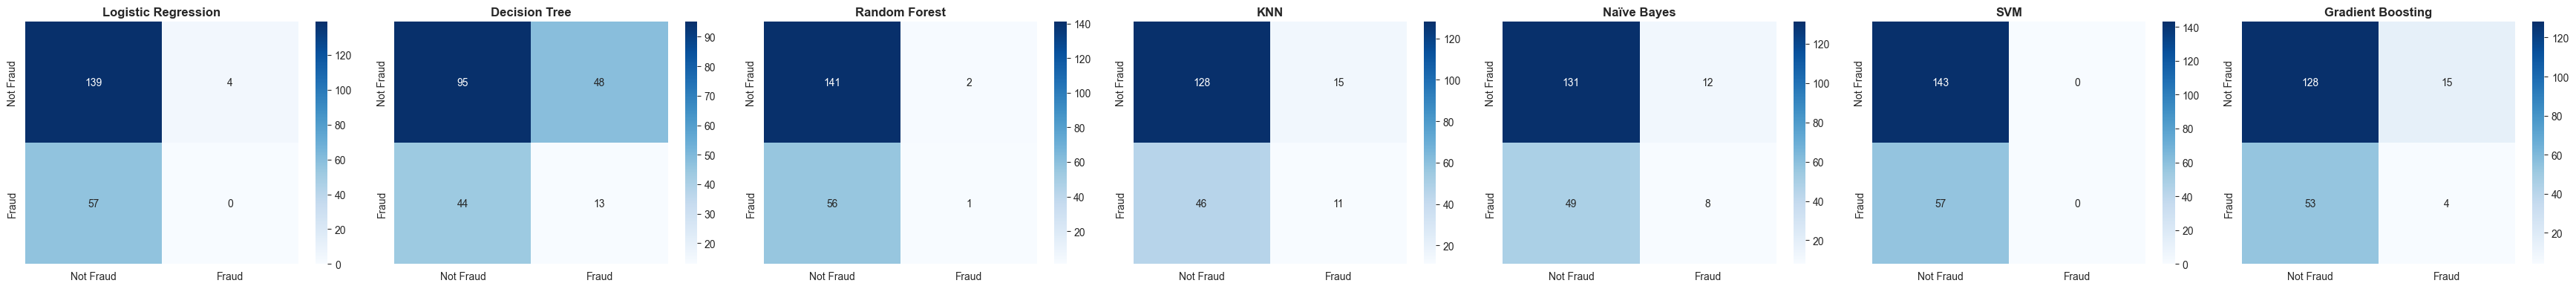

In [449]:
# Final performance visualization: Confusion Matrices
fig, axes = plt.subplots(1, 7, figsize=(35, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, 
                xticklabels=["Not Fraud", "Fraud"], 
                yticklabels=["Not Fraud", "Fraud"])
    ax.set_title(name, fontweight="bold")
plt.tight_layout()
plt.show()

## EPIC 6 — INTEGRATE WITH WEB FRAMEWORK

In this section, we will be building a web application that is integrated to the model we built. A UI is provided for the uses where he has to enter the values for predictions. The enter values are given to the saved model and prediction is showcased on the UI. This section has the following tasks

● Building HTML Pages

● Building server-side script

● Run the web application

**Activity 2.1: Building Html Page**: For this project create HTML file namely index.html and save them in the templates folder. Refer this link for templates.

**Import the libraries**

Load the saved model. Importing the flask module in the project is mandatory. An object of Flask class is our WSGI application. Flask constructor takes the name of the current module ( name ) as argument.

**Render HTML page**:

Here we will be using a declared constructor to route to the HTML page which we have created earlier.

In the above example, ‘/’ URL is bound with the index.html function. Hence, when the home page of the web server is opened in the browser, the html page will be rendered. Whenever you enter the values from the html page the values can be retrieved using POST Method.

**Retrieves the value from UI**:

Here we are routing our app to predict() function. This function retrieves all the values from the HTML page using Post request. That is stored in an array. This array is passed to the model.predict() function. This function returns the prediction. And this prediction value will be rendered to the text that we have mentioned in the submit.html page earlier.

**Main Function**:

● Open anaconda prompt from the start menu

● Navigate to the folder where your python script is.

● Now type “python app.py” command

● Navigate to the localhost where you can view your web page. ● Click on the predict button from the top left corner, enter the inputs, click on the submit button, and see the result/prediction on the web.

Now, Go the web browser and write the localhost url (http://127.0.0.1:5000) to get the results.